# Machine Learning - Assignment 2: Applying ML Algorithms

## Student Name: Shatha Rasmy Abu Jazar

## Student Number: 2320230176

### Dataset: Customer Personality Analysis Dataset

In this notebook, I will apply different machine learning techniques to the Customer Personality Analysis dataset.

The work includes data preprocessing, feature engineering, regression, classification, and clustering tasks.

The main goal is to prepare the data, build machine learning models, evaluate their performance using appropriate metrics, and gain useful insights about customer behavior.




## Importing Libraries


In this step, I imported the main libraries that I will need in this assignment. I will use them for reading the dataset, cleaning and processing the data, creating visualizations, building machine learning models, and evaluating the results.



In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Master Preprocessing Function

For better code organization, I created a preprocessing function that contains the main data cleaning and feature engineering steps The preprocessing steps were applied explicitly throughout the notebook .


In [2]:
def preprocess_data(df):

    # Handle missing values
    df["Income"] = df["Income"].fillna(df["Income"].median())

    # Feature Engineering
    df["Age"] = 2026 - df["Year_Birth"]

    df["TotalSpending"] = (
        df["MntWines"]
        + df["MntFruits"]
        + df["MntMeatProducts"]
        + df["MntFishProducts"]
        + df["MntSweetProducts"]
        + df["MntGoldProds"]
    )

    df["TotalChildren"] = (
        df["Kidhome"]
        + df["Teenhome"]
    )

    # Filtering
    df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]
    df = df[df["Income"] > 0]

    # Education Encoding
    education_mapping = {
        "Basic": 0,
        "2n Cycle": 1,
        "Graduation": 2,
        "Master": 3,
        "PhD": 4
    }

    df["Education"] = df["Education"].map(education_mapping)

    # Group rare marital status categories
    top_categories = [
        "Married",
        "Together",
        "Single",
        "Divorced"
    ]

    df["Marital_Status"] = df["Marital_Status"].apply(
        lambda x: x if x in top_categories else "Other"
    )

    # One-Hot Encoding
    df = pd.get_dummies(
        df,
        columns=["Marital_Status"],
        dtype=int
    )

    # Remove unused date column
    df = df.drop("Dt_Customer", axis=1)

    return df

## Loading and Inspecting the Dataset

In this step, I loaded the dataset using the pd.read_csv() function and stored it in a DataFrame called df. I used sep="\t" because the dataset columns are separated by tabs. Then, I displayed the first 5 rows using head() to get an initial understanding of the data and verify that it was loaded correctly.


In [3]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Dataset Information

Here, I checked the dimensions of the dataset and reviewed the data types of each column. This helps me understand what kind of data I am working with and identify columns that may need preprocessing.



In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (2240, 29)


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Checking Missing Values

In this step, I checked for missing values in the dataset using isnull().sum(). This helps me identify which columns contain missing data and determine the appropriate method to handle them before building machine learning models.


In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


The output shows that most columns do not contain any missing values. However, the Income column contains 24 missing values. Therefore, I will handle these missing values using median imputation before proceeding with feature engineering and model building.


In [7]:
# Fill missing values in Income using the median
df["Income"] = df["Income"].fillna(df["Income"].median())


In [8]:
df["Income"].isnull().sum()

0

The result shows that there are no remaining missing values in the Income column after applying median imputation. This confirms that the missing data was handled successfully and the dataset is now ready for the next preprocessing steps.

## EDA

### Income Distribution

I visualized the distribution of customer income to better understand the spread of income values and identify potential outliers.

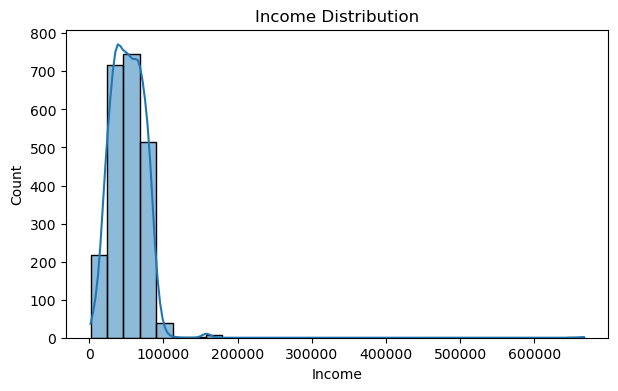

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(df["Income"], bins=30, kde=True)

plt.title("Income Distribution")
plt.show()

### Correlation Analysis

I created a correlation heatmap to examine the relationships between the numerical features and identify important patterns.

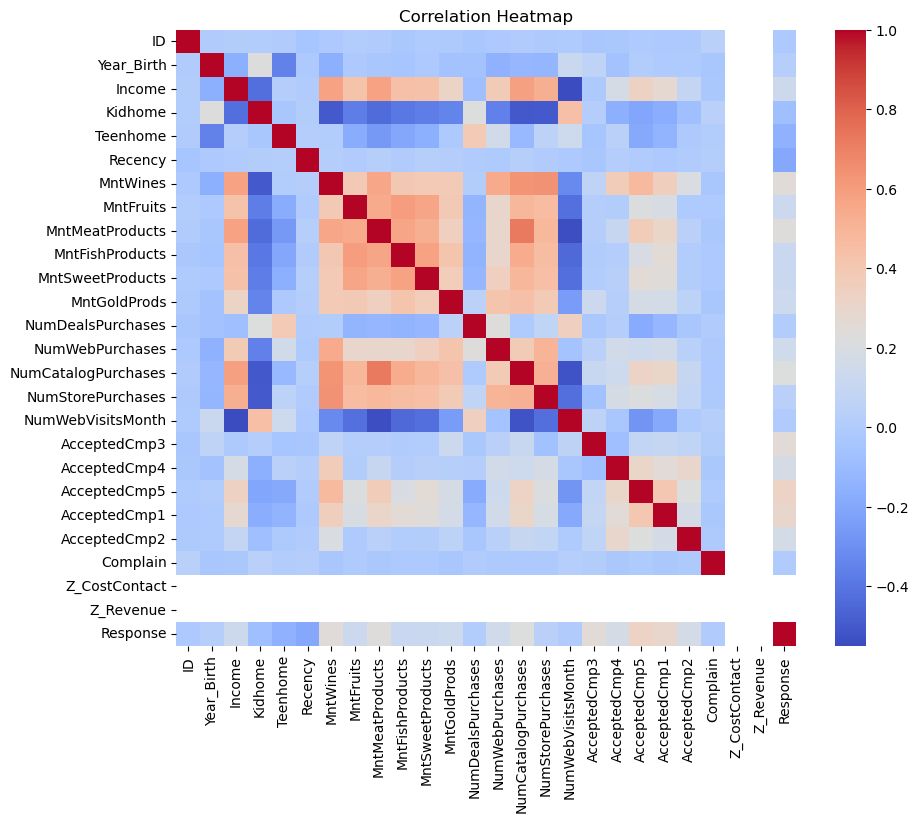

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

The Income distribution is right-skewed, indicating that most customers have moderate incomes while a smaller group has very high incomes. The correlation heatmap reveals a positive relationship between Income and TotalSpending, suggesting that higher-income customers tend to spend more on products.

## Feature Engineering

In this step, I created new features that may help improve the performance of the machine learning models. I created Age from Year_Birth, TotalSpending by summing all product spending columns, and TotalChildren by combining Kidhome and Teenhome. These new features provide more meaningful information about customer behavior and household characteristics.


In [11]:
df["Age"] = 2026 - df["Year_Birth"]

df["TotalSpending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

df[["Age", "TotalSpending", "TotalChildren"]].head()

,Age,TotalSpending,TotalChildren
0,69,1617,0
1,72,27,2
2,61,776,0
3,42,53,1
4,45,422,1


The Age distribution shows that the dataset mainly contains middle-aged and older customers.

## Age Distribution

I visualized the age distribution of customers to understand the demographic characteristics of the dataset.


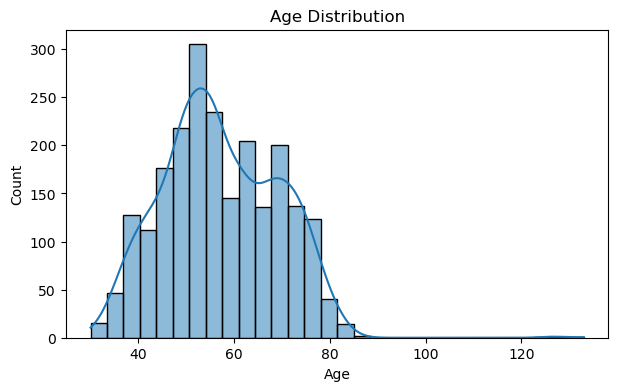

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()



The Income distribution is right-skewed, indicating that most customers have moderate incomes while a smaller group has very high incomes. The Age distribution shows that the dataset mainly contains middle-aged and older customers. The correlation heatmap reveals a positive relationship between Income and TotalSpending, suggesting that higher-income customers tend to spend more on products.


## Filtering Unrealistic Values

In this step, I removed unrealistic records from the dataset. I filtered out customers whose age is less than 18 or greater than 100. I also removed rows with zero income because they may negatively affect the analysis and model performance.


In [13]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

df = df[df["Income"] > 0]

df.shape

(2237, 32)


The dataset originally contained 2240 records. After removing unrealistic ages and zero-income records, the dataset contains 2237 records and 32 columns. This means that 3 records were removed during the filtering process.


## Exploring Categorical Features

Before applying encoding techniques, I explored the categorical columns to identify their unique values. This helps me choose the appropriate encoding method and verify the categories that exist in the dataset.


In [14]:
print("Education Categories:")
print(df["Education"].unique())

print("\nMarital Status Categories:")
print(df["Marital_Status"].unique())

Education Categories:
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

Marital Status Categories:
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


### Encoding Education

In this step, I converted the Education column into numerical values using manual label encoding. Machine learning algorithms work better with numerical data, so categorical education levels need to be represented as numbers before model training.


In [15]:
education_mapping = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}

df["Education"] = df["Education"].map(education_mapping)

df["Education"].head()

0    2
1    2
2    2
3    2
4    4
Name: Education, dtype: int64

### Checking Marital Status Distribution

Before applying one-hot encoding, I examined the frequency of each marital status category. This helps me identify the most common categories and group the less frequent categories into a single category called "Other".



In [16]:
df["Marital_Status"].value_counts()

Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64

### Grouping Rare Categories

In this step, I grouped the less frequent marital status categories into a single category called "Other". This helps reduce the number of categories and prevents very small groups from negatively affecting the machine learning models.


In [17]:
top_categories = ["Married", "Together", "Single", "Divorced"]

df["Marital_Status"] = df["Marital_Status"].apply(
    lambda x: x if x in top_categories else "Other"
)

df["Marital_Status"].value_counts()

Married     864
Together    579
Single      479
Divorced    231
Other        84
Name: Marital_Status, dtype: int64

## One-Hot Encoding Marital Status

In this step, I used pd.get_dummies() to convert the Marital_Status column into multiple binary columns. Each category is represented by a separate column containing values of 0 or 1. This allows machine learning algorithms to work with categorical information more effectively.

In [18]:
df = pd.get_dummies(df, columns=["Marital_Status"], dtype=int)

df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,2,58138.0,0,0,04-09-2012,58,635,88,...,11,1,69,1617,0,0,0,0,1,0
1,2174,1954,2,46344.0,1,1,08-03-2014,38,11,1,...,11,0,72,27,2,0,0,0,1,0
2,4141,1965,2,71613.0,0,0,21-08-2013,26,426,49,...,11,0,61,776,0,0,0,0,0,1
3,6182,1984,2,26646.0,1,0,10-02-2014,26,11,4,...,11,0,42,53,1,0,0,0,0,1
4,5324,1981,4,58293.0,1,0,19-01-2014,94,173,43,...,11,0,45,422,1,0,1,0,0,0


### Checking Data Types After Preprocessing

After completing the preprocessing steps, I reviewed the data types of all columns. This helps me identify any remaining non-numeric features that may require additional processing before training machine learning models.


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2237 entries, 0 to 2239
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2237 non-null   int64  
 1   Year_Birth               2237 non-null   int64  
 2   Education                2237 non-null   int64  
 3   Income                   2237 non-null   float64
 4   Kidhome                  2237 non-null   int64  
 5   Teenhome                 2237 non-null   int64  
 6   Dt_Customer              2237 non-null   object 
 7   Recency                  2237 non-null   int64  
 8   MntWines                 2237 non-null   int64  
 9   MntFruits                2237 non-null   int64  
 10  MntMeatProducts          2237 non-null   int64  
 11  MntFishProducts          2237 non-null   int64  
 12  MntSweetProducts         2237 non-null   int64  
 13  MntGoldProds             2237 non-null   int64  
 14  NumDealsPurchases       

### Removing Unused Date Column

In this step, I removed the Dt_Customer column because it contains date values stored as text and is not required for the regression, classification, or clustering tasks in this assignment. Removing unused features helps simplify the dataset and avoids issues during model training.


In [20]:
df = df.drop("Dt_Customer", axis=1)

df.shape

(2237, 35)

## Preparing Data for Regression

In this step, I prepared the dataset for the regression task. The target variable is TotalSpending, which represents the total amount spent by each customer. I separated the target variable from the input features so that the machine learning models can learn the relationship between customer characteristics and spending behavior.


In [21]:
X_reg = df.drop("TotalSpending", axis=1)
y_reg = df["TotalSpending"]

print("Features Shape:", X_reg.shape)
print("Target Shape:", y_reg.shape)

Features Shape: (2237, 34)
Target Shape: (2237,)


## Splitting the Data

In this step, I divided the dataset into training and testing sets using train_test_split(). I used 80% of the data for training and 20% for testing. This allows me to evaluate the model on unseen data and measure its performance more reliably.


In [22]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train_reg.shape)
print("Testing Set:", X_test_reg.shape)

Training Set: (1789, 34)
Testing Set: (448, 34)



The dataset was successfully divided into training and testing sets. The training set contains 1789 records and will be used to train the regression models, while the testing set contains 448 records and will be used to evaluate model performance on unseen data.

In [23]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response',
 'Age',
 'TotalSpending',
 'TotalChildren',
 'Marital_Status_Divorced',
 'Marital_Status_Married',
 'Marital_Status_Other',
 'Marital_Status_Single',
 'Marital_Status_Together']

### Removing Leakage Features

Before training the regression models, I removed the spending-related features that were used to create the target variable TotalSpending. Keeping these features would introduce data leakage because the target variable is directly calculated from them.


In [24]:
leakage_features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

X_reg = X_reg.drop(columns=leakage_features)

print("Features Shape:", X_reg.shape)

Features Shape: (2237, 28)


### Updating the Train-Test Split

After removing the leakage features, I repeated the train-test split to ensure that the training and testing datasets contain the updated set of features. This guarantees that the regression models will be trained using the correct inputs.

In [25]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train_reg.shape)
print("Testing Set:", X_test_reg.shape)

Training Set: (1789, 28)
Testing Set: (448, 28)


## Feature Scaling

In this step, I applied StandardScaler to standardize the feature values. Scaling helps machine learning algorithms perform better by transforming the features to a similar scale with a mean close to 0 and a standard deviation close to 1. The scaler was fitted on the training data only and then applied to both the training and testing sets to avoid data leakage.

In [26]:
scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)

X_test_reg_scaled = scaler.transform(X_test_reg)

print("Scaled Training Shape:", X_train_reg_scaled.shape)
print("Scaled Testing Shape:", X_test_reg_scaled.shape)

Scaled Training Shape: (1789, 28)
Scaled Testing Shape: (448, 28)


## Linear Regression Model

In this step, I trained a Linear Regression model using the scaled training data. Linear Regression is one of the most common regression algorithms and is used to predict continuous values by learning the relationship between the input features and the target variable.

In [27]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_linear = linear_model.predict(X_test_reg_scaled)

## Evaluating Linear Regression

After training the model, I evaluated its performance using MSE, RMSE, and R² Score. These metrics help measure prediction error and determine how well the model explains the variation in the target variable.

In [28]:
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test_reg, y_pred_linear)

print("Linear Regression Results")
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
MSE : 70755.8496381445
RMSE: 265.9997173647831
R² Score: 0.8137387310862476



The Linear Regression model achieved an R² Score of approximately 0.81, which indicates that the model can explain about 81% of the variation in TotalSpending. The RMSE value shows the average prediction error in the same unit as the target variable. Overall, the model provides a reasonably good baseline for predicting customer spending.


## Ridge Regression Model


In this step, I trained a Ridge Regression model with alpha=1.0. Ridge Regression is an extension of Linear Regression that applies regularization to reduce overfitting and improve the model's ability to generalize to unseen data.


In [29]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_ridge = ridge_model.predict(X_test_reg_scaled)

## Evaluating Ridge Regression

After training the Ridge Regression model, I evaluated its performance using MSE, RMSE, and R² Score. These metrics allow me to compare the performance of Ridge Regression with Linear Regression and determine whether regularization improves the model.


In [30]:
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)

print("Ridge Regression Results")
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R² Score:", r2_ridge)

Ridge Regression Results
MSE : 70744.83043670288
RMSE: 265.97900375161737
R² Score: 0.8137677385881493



The Ridge Regression model achieved slightly better results than Linear Regression. The MSE and RMSE values decreased slightly, while the R² Score increased. This indicates that regularization helped improve the model's generalization ability, although the improvement was relatively small.


## Decision Tree Regressor Model

In this step, I trained a Decision Tree Regressor with max_depth=5. Decision Trees learn decision rules from the training data and can capture non-linear relationships between the features and the target variable.


In [31]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train_reg, y_train_reg)

y_pred_tree = tree_model.predict(X_test_reg)

## Evaluating Decision Tree Regressor

After training the Decision Tree Regressor, I evaluated its performance using MSE, RMSE, and R² Score. These metrics allow me to compare the Decision Tree model with the previous regression models.


In [32]:
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test_reg, y_pred_tree)

print("Decision Tree Results")
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R² Score:", r2_tree)

Decision Tree Results
MSE : 55258.56598550052
RMSE: 235.0714061418371
R² Score: 0.8545345625633625




The Decision Tree Regressor achieved the best performance among all regression models. It produced the lowest MSE and RMSE values and the highest R² Score. This indicates that the model was able to capture more complex relationships in the data and provide more accurate predictions of customer spending.


## Regression Models Comparison

To compare the performance of the regression models, I summarized their evaluation metrics in a single table. This makes it easier to identify the best-performing model based on MSE, RMSE, and R² Score.


In [33]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree Regressor"
    ],
    "MSE": [
        mse_linear,
        mse_ridge,
        mse_tree
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_tree
    ],
    "R2 Score": [
        r2_linear,
        r2_ridge,
        r2_tree
    ]
})

regression_results = regression_results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

regression_results.index = regression_results.index + 1
regression_results

,Model,MSE,RMSE,R2 Score
1,Decision Tree Regressor,55258.565986,235.071406,0.854535
2,Ridge Regression,70744.830437,265.979004,0.813768
3,Linear Regression,70755.849638,265.999717,0.813739


### Regression Conclusion

Based on the evaluation results, the Decision Tree Regressor achieved the highest R² Score and the lowest prediction error. Therefore, it is the best-performing regression model for predicting TotalSpending in this dataset.


## Checking Class Distribution

Before building the classification models, I examined the distribution of the target variable Response. This helps me determine whether the dataset is balanced or imbalanced and choose the appropriate classification approach.


In [34]:
df["Response"].value_counts()

0    1903
1     334
Name: Response, dtype: int64

## Visualizing Class Distribution

To better understand the class distribution, I created a count plot for the Response variable. This visualization makes it easier to identify any class imbalance in the dataset.


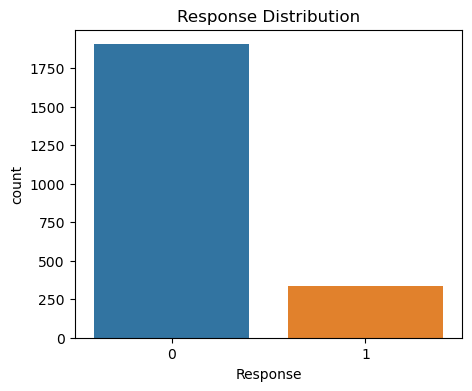

In [35]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Response", data=df)

plt.title("Response Distribution")
plt.show()

### Class Distribution Analysis

The class distribution shows a clear imbalance in the target variable. Approximately 85% of the customers belong to class 0, while only about 15% belong to class 1. This imbalance should be considered when evaluating classification models because accuracy alone may not provide a complete picture of model performance.



## Supervised Learning - Classification

## Preparing Data for Classification

In this step, I prepared the dataset for the classification task. The target variable is Response, and the remaining features will be used to predict whether a customer responds to the marketing campaign.

In [36]:
X_cls = df.drop("Response", axis=1)
y_cls = df["Response"]

print("Features Shape:", X_cls.shape)
print("Target Shape:", y_cls.shape)

Features Shape: (2237, 34)
Target Shape: (2237,)


## Splitting Classification Data

In this step, I divided the classification dataset into training and testing sets using train_test_split(). I used 80% of the data for training and 20% for testing to evaluate the model on unseen observations.


In [37]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Training Set:", X_train_cls.shape)
print("Testing Set:", X_test_cls.shape)

Training Set: (1789, 34)
Testing Set: (448, 34)


### Feature Scaling

Before training the classification models, I applied StandardScaler to standardize the feature values. Scaling helps improve the performance of distance-based algorithms such as KNN.


In [38]:
scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("Scaled Training Shape:", X_train_cls_scaled.shape)
print("Scaled Testing Shape:", X_test_cls_scaled.shape)

Scaled Training Shape: (1789, 34)
Scaled Testing Shape: (448, 34)


## Logistic Regression Model

In this step, I trained a Logistic Regression model using the scaled training data. Logistic Regression is a widely used classification algorithm that predicts the probability of belonging to a specific class.


In [39]:
log_model = LogisticRegression(class_weight="balanced", random_state=42)

log_model.fit(X_train_cls_scaled, y_train_cls)

y_pred_log = log_model.predict(X_test_cls_scaled)

## Evaluating Logistic Regression

After training the Logistic Regression model, I evaluated its performance using Accuracy, Precision, Recall, and F1 Score. These metrics provide a comprehensive evaluation of classification performance.



In [40]:
acc_log = accuracy_score(y_test_cls, y_pred_log)
prec_log = precision_score(y_test_cls, y_pred_log)
rec_log = recall_score(y_test_cls, y_pred_log)
f1_log = f1_score(y_test_cls, y_pred_log)

print("Logistic Regression Results")
print("Accuracy :", acc_log)
print("Precision:", prec_log)
print("Recall   :", rec_log)
print("F1 Score :", f1_log)

Logistic Regression Results
Accuracy : 0.8147321428571429
Precision: 0.4344262295081967
Recall   : 0.7910447761194029
F1 Score : 0.5608465608465608


## Confusion Matrix

To better understand the classification results, I displayed the confusion matrix. It shows the number of correct and incorrect predictions for each class.


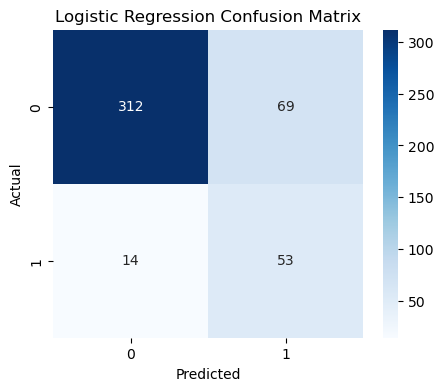

In [41]:
cm_log = confusion_matrix(y_test_cls, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
print(classification_report(y_test_cls, y_pred_log))

              precision    recall  f1-score   support

           0       0.96      0.82      0.88       381
           1       0.43      0.79      0.56        67

    accuracy                           0.81       448
   macro avg       0.70      0.80      0.72       448
weighted avg       0.88      0.81      0.83       448



#### Logistic Regression Results

The Logistic Regression model achieved lower accuracy after using class_weight="balanced", but the recall improved significantly. This means the model became better at identifying customers who actually responded to the campaign, which is important because the dataset is imbalanced. A higher recall helps reduce false negatives and allows the model to capture more potential responders.
.

## K-Nearest Neighbors Model

In this step, I trained a K-Nearest Neighbors classifier using k=5. KNN classifies new observations based on the majority class among the nearest neighboring samples.

In [43]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_cls_scaled, y_train_cls)

y_pred_knn = knn_model.predict(X_test_cls_scaled)

## Evaluating KNN

After training the KNN model, I evaluated its performance using Accuracy, Precision, Recall, and F1 Score to compare it with Logistic Regression.

In [44]:
acc_knn = accuracy_score(y_test_cls, y_pred_knn)
prec_knn = precision_score(y_test_cls, y_pred_knn)
rec_knn = recall_score(y_test_cls, y_pred_knn)
f1_knn = f1_score(y_test_cls, y_pred_knn)

print("KNN Results")
print("Accuracy :", acc_knn)
print("Precision:", prec_knn)
print("Recall   :", rec_knn)
print("F1 Score :", f1_knn)

KNN Results
Accuracy : 0.8705357142857143
Precision: 0.6451612903225806
Recall   : 0.29850746268656714
F1 Score : 0.40816326530612246


## KNN Confusion Matrix

I displayed the confusion matrix to analyze the classification performance of the KNN model and observe the number of correct and incorrect predictions.


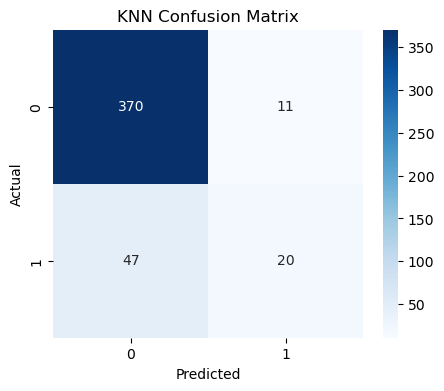

In [45]:
cm_knn = confusion_matrix(y_test_cls, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
print(classification_report(y_test_cls, y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.65      0.30      0.41        67

    accuracy                           0.87       448
   macro avg       0.77      0.63      0.67       448
weighted avg       0.85      0.87      0.85       448



### KNN Results
The KNN model achieved lower performance compared to Logistic Regression. Although the accuracy remained relatively high, the recall and F1 Score were lower, indicating that the model struggled to correctly identify customers who responded to the campaign.

## Random Forest Classifier

In this step, I trained a Random Forest classifier using 100 decision trees. Random Forest combines the predictions of multiple decision trees to improve classification performance and reduce overfitting.



In [47]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_cls, y_train_cls)

# Predictions
y_pred_rf = rf_model.predict(X_test_cls)

## Evaluating Random Forest

After training the Random Forest model, I evaluated its performance using Accuracy, Precision, Recall, and F1 Score. These metrics help determine how well the model classifies customer responses.

In [48]:
acc_rf = accuracy_score(y_test_cls, y_pred_rf)
prec_rf = precision_score(y_test_cls, y_pred_rf)
rec_rf = recall_score(y_test_cls, y_pred_rf)
f1_rf = f1_score(y_test_cls, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)

Random Forest Results
Accuracy : 0.8683035714285714
Precision: 0.6538461538461539
Recall   : 0.2537313432835821
F1 Score : 0.3655913978494624


## Random Forest Confusion Matrix

I displayed the confusion matrix to analyze the classification performance of the Random Forest model and identify correct and incorrect predictions.

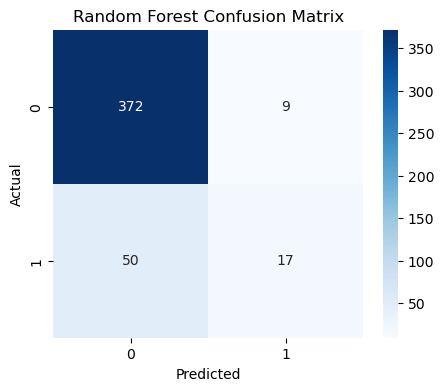

In [49]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
print(classification_report(y_test_cls, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       381
           1       0.65      0.25      0.37        67

    accuracy                           0.87       448
   macro avg       0.77      0.62      0.65       448
weighted avg       0.85      0.87      0.84       448



### Random Forest Results

The Random Forest model achieved good classification accuracy. However, its Recall and F1 Score were lower than those of Logistic Regression. This indicates that the model had more difficulty identifying customers who responded to the campaign.
 

### Classification Models Comparison

To compare the classification models, I summarized the evaluation metrics in a single table. This makes it easier to identify the best-performing classifier.


In [51]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        acc_log,
        acc_knn,
        acc_rf
    ],
    "Precision": [
        prec_log,
        prec_knn,
        prec_rf
    ],
    "Recall": [
        rec_log,
        rec_knn,
        rec_rf
    ],
    "F1 Score": [
        f1_log,
        f1_knn,
        f1_rf
    ]
})

classification_results = classification_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

classification_results.index += 1

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.814732,0.434426,0.791045,0.560847
2,KNN,0.870536,0.645161,0.298507,0.408163
3,Random Forest,0.868304,0.653846,0.253731,0.365591


## Classification Conclusion

In this classification problem, Recall is the most important metric because the goal is to identify customers who are likely to respond to the marketing campaign. Missing a potential customer (False Negative) is more costly than incorrectly predicting that a customer will respond. Therefore, a higher Recall helps capture more potential responders and improves the effectiveness of marketing decisions.


## Unsupervised Learning - Clustering

## Selecting Features for Clustering

For customer segmentation, I selected four important features: Income, TotalSpending, Age, and TotalChildren. These features provide useful information about customer demographics and purchasing behavior.

In [52]:
cluster_features = df[
    ["Income", "TotalSpending", "Age", "TotalChildren"]
]

cluster_features.head()

,Income,TotalSpending,Age,TotalChildren
0,58138.0,1617,69,0
1,46344.0,27,72,2
2,71613.0,776,61,0
3,26646.0,53,42,1
4,58293.0,422,45,1


## Scaling Clustering Features

Before applying K-Means clustering, I standardized the selected features using StandardScaler. This ensures that all features contribute equally to the clustering process.

In [53]:
cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_features
)

cluster_scaled.shape

(2237, 4)

## Elbow Method

To determine the optimal number of clusters, I used the Elbow Method. The inertia value was calculated for cluster numbers ranging from 1 to 10.

In [54]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    inertia.append(kmeans.inertia_)

## Elbow Curve

I plotted the inertia values against the number of clusters to identify the optimal cluster count.

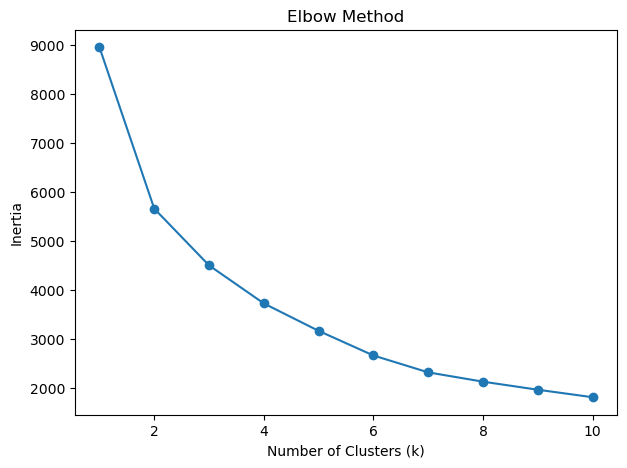

In [55]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## K-Means Clustering

Based on the Elbow Method, I selected k=4 as the optimal number of clusters. I then trained a K-Means model and assigned a cluster label to each customer.

In [56]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

df["Cluster"] = clusters

df["Cluster"].value_counts()

3    732
1    584
2    463
0    458
Name: Cluster, dtype: int64

## PCA for Visualization

To visualize the clusters in two dimensions, I applied PCA and reduced the four clustering features to two principal components.


In [57]:
pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

pca_df = pd.DataFrame(
    cluster_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"]

## Cluster Visualization

I created a scatter plot using the two PCA components and colored the points according to their cluster labels.

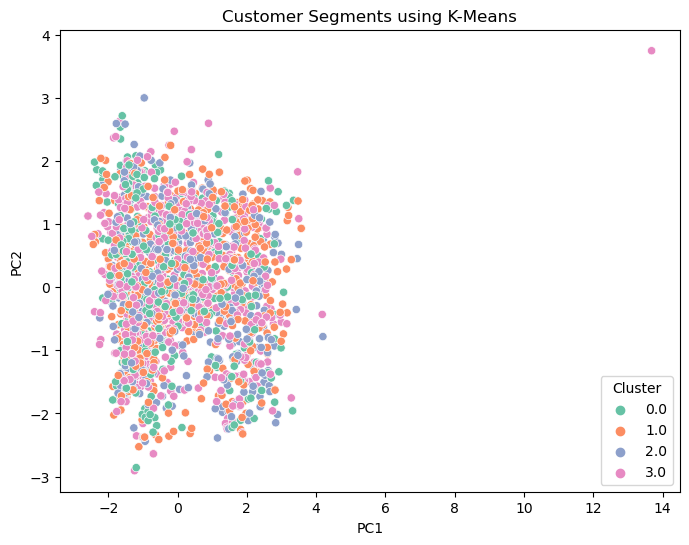

In [58]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments using K-Means")
plt.show()

## Cluster Profiling

To understand the characteristics of each cluster, I calculated the mean values of Income, TotalSpending, Age, and TotalChildren for every cluster.

In [59]:
cluster_profile = df.groupby("Cluster")[
    ["Income", "TotalSpending", "Age", "TotalChildren"]
].mean()

cluster_profile

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,44108.534934,222.812227,60.589520,2.115721
1,61336.053082,802.909247,69.142123,0.688356
2,78094.845572,1434.786177,51.498920,0.285097
3,33678.734290,163.654372,48.846995,0.852459


## Cluster Interpretation

**Cluster 0**
- Medium income customers.
- Low spending behavior.
- Older customers.
- Highest number of children.
- Segment Description: Family-oriented customers with moderate income and low spending.

**Cluster 1**
- High income customers.
- High spending behavior.
- Older customers.
- Few children.
- Segment Description: High-income and high-spending loyal customers.

**Cluster 2**
- Highest income customers.
- Highest spending behavior.
- Younger than Cluster 1.
- Very few children.
- Segment Description: Premium customers with very high purchasing power.

**Cluster 3**
- Lowest income customers.
- Lowest spending behavior.
- Youngest customers.
- Few children.
- Segment Description: Young low-income customers with limited spending activity.

